# [CE Cam](../../../Costellazioni/Camelopardalis/CE_Cam.html) del [31/10/2025](../Index.html)

In [1]:
import sys
sys.path.append('../../../src')
import spectrum as spec
import pandas as pd

## Camera Settings

- Gain=200
- Exposure=30.000s
- Brightness=5
- Temperature=-10
- StartCapture=2025-10-31T17:32:29.7613685Z
- EndCapture=2025-10-31T17:52:53.2065580Z



























## Raw Spectrum

Spettro ottenuto come media di 40 immagini. Applicati bias, dark e flat. Elaborazione con ISIS

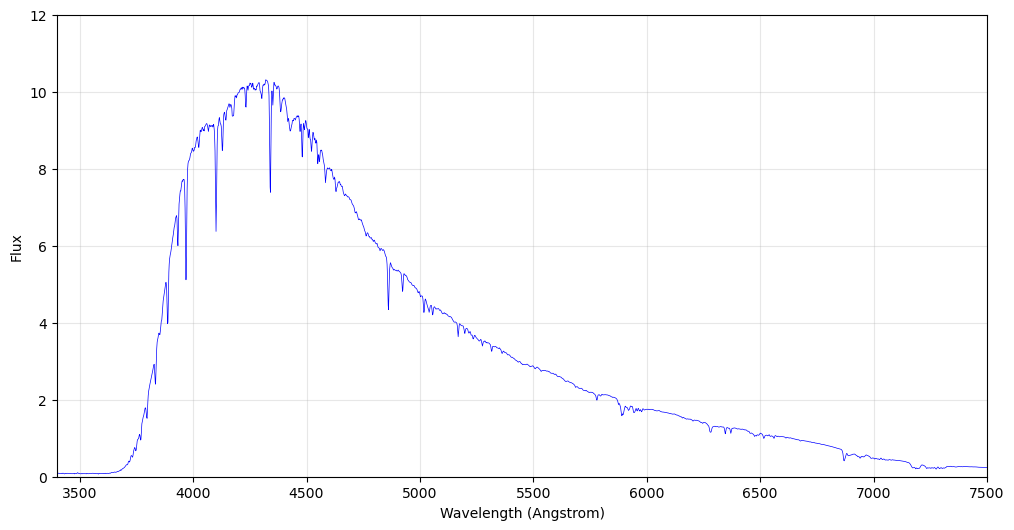

In [2]:
raw_wavelength, raw_flux = spec.load("_cecam_20251031_731.fit")
raw_flux = spec.cleanup_flux(raw_flux)
spec.simple_plot(raw_wavelength, raw_flux, wl_range = (3400, 7500), flux_range=(0.0,12.0))

## Rectified Spectrum [download](_alkaid_20250808_874-rect)

In [3]:
wavelength, flux = spec.load("_cecam_20251031_731-rect.fit")
flux = spec.cleanup_flux(flux)
print(f"SNR Reale stimato: {spec.calc_snr(wavelength, flux, 6695, 6785):.1f}")

SNR Reale stimato: 442.0


In [4]:
spectral_lines_summary = pd.read_csv('CE Cam spec - Summary.csv', usecols=[0, 1, 2], names=["name","class","wavelength"])
spectral_lines_all = pd.read_csv('CE Cam spec - 2025-10-31.csv', usecols=[0, 1, 2], names=["name","class","wavelength"])

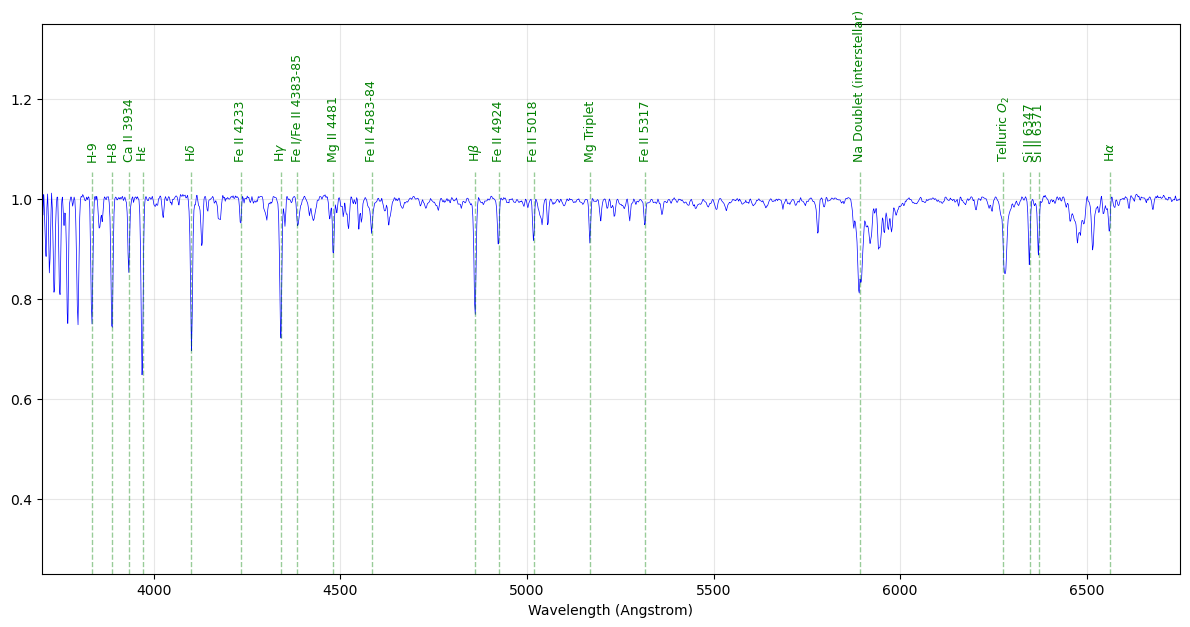

In [18]:
spec.plot_with_lines(wavelength, flux, spectral_lines_summary, (3700,6750), (0.25,1.35))

### Zoom  370 - 400 nm

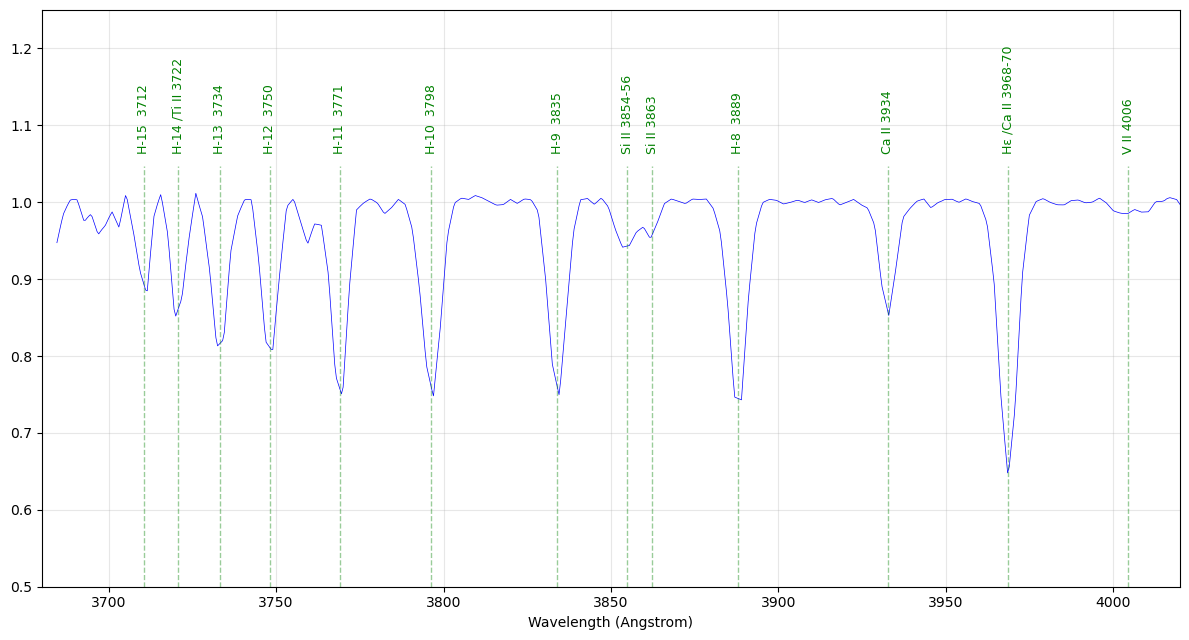

In [6]:
spec.plot_with_lines(wavelength, flux, spectral_lines_all, (3680,4020), (0.50,1.25))

### Zoom  400 - 430 nm

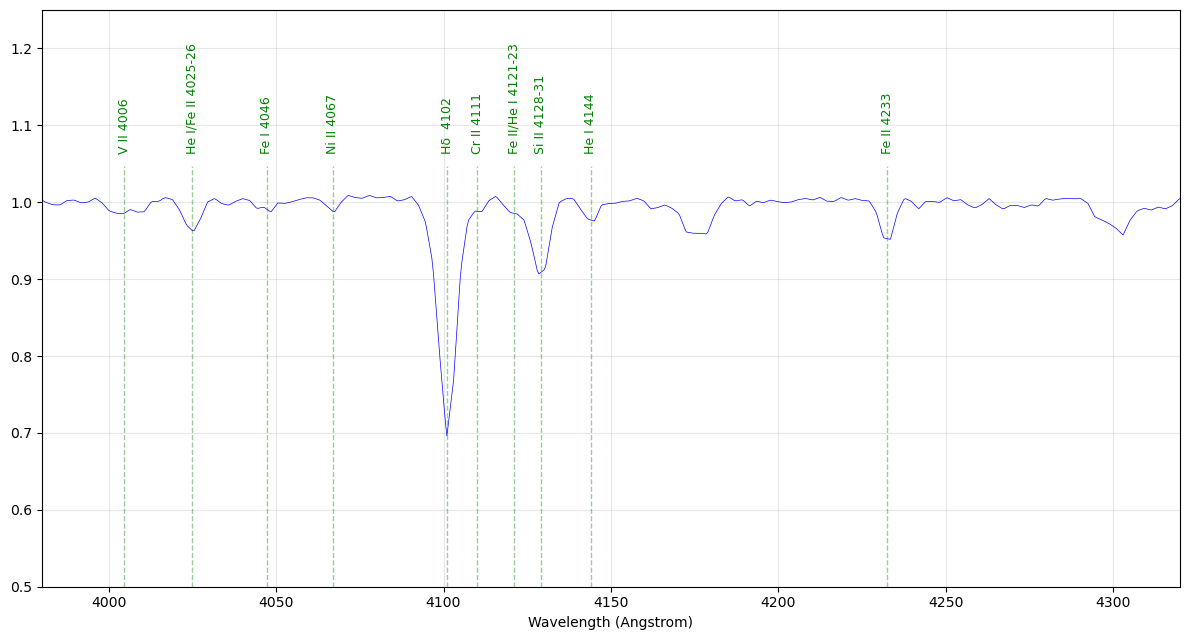

In [7]:
spec.plot_with_lines(wavelength, flux, spectral_lines_all, (3980,4320), (0.50,1.25))

### Zoom 430 - 460 nm

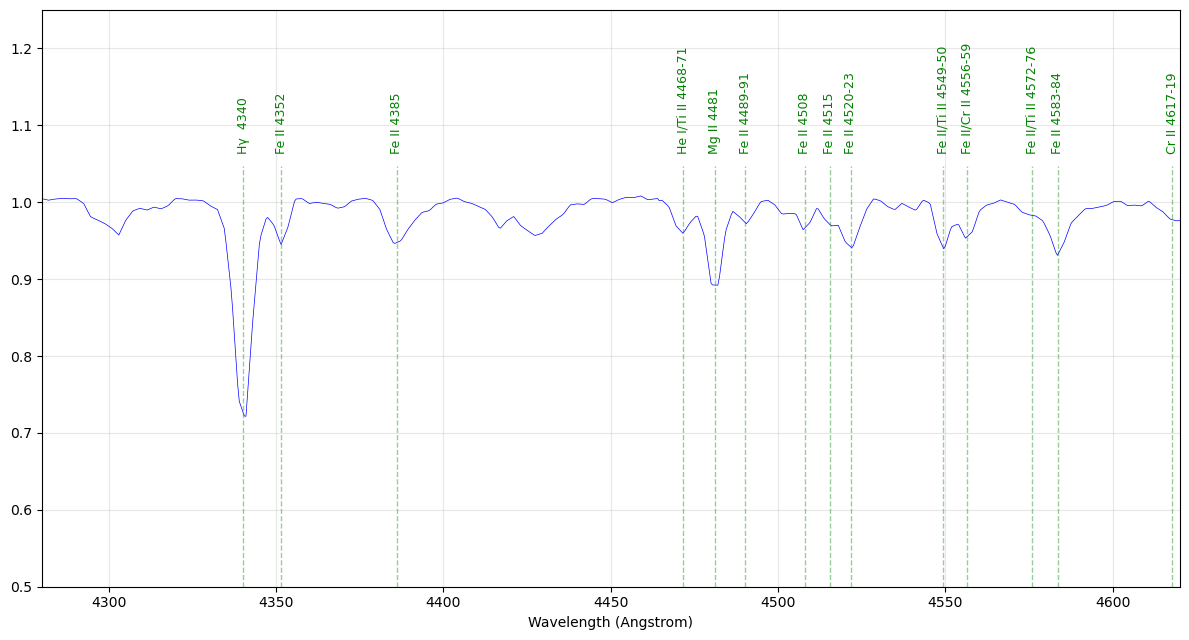

In [8]:
spec.plot_with_lines(wavelength, flux, spectral_lines_all, (4280,4620), (0.50,1.25))

### Zoom  460 - 490 nm

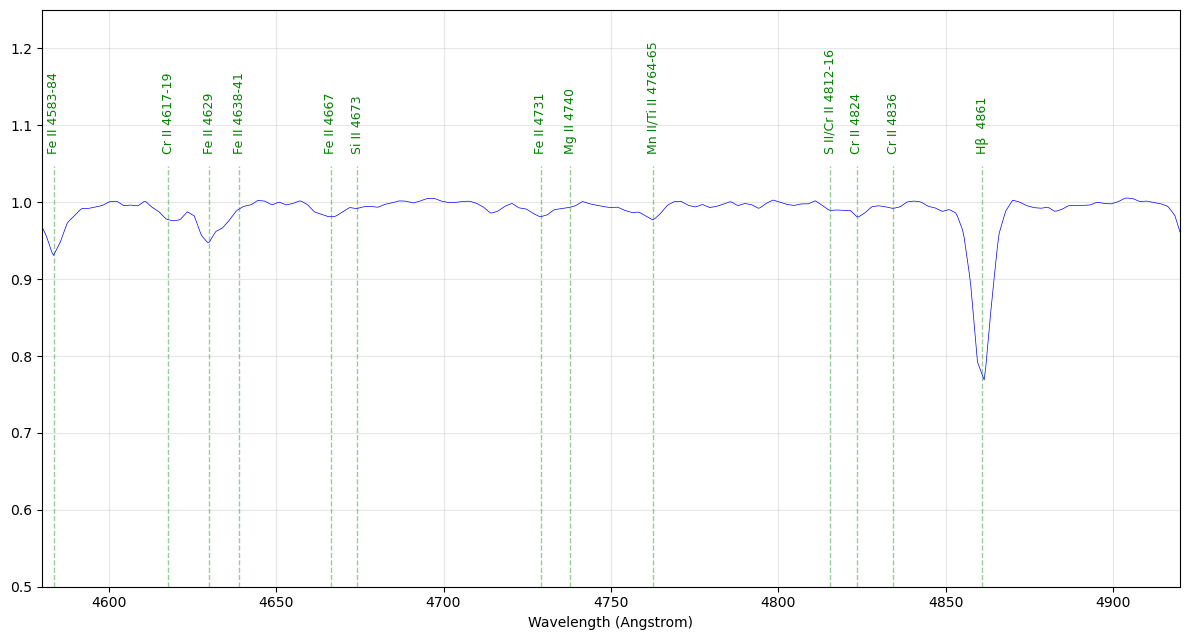

In [9]:
spec.plot_with_lines(wavelength, flux, spectral_lines_all, (4580,4920), (0.50,1.25))

### Zoom  490 - 540 nm

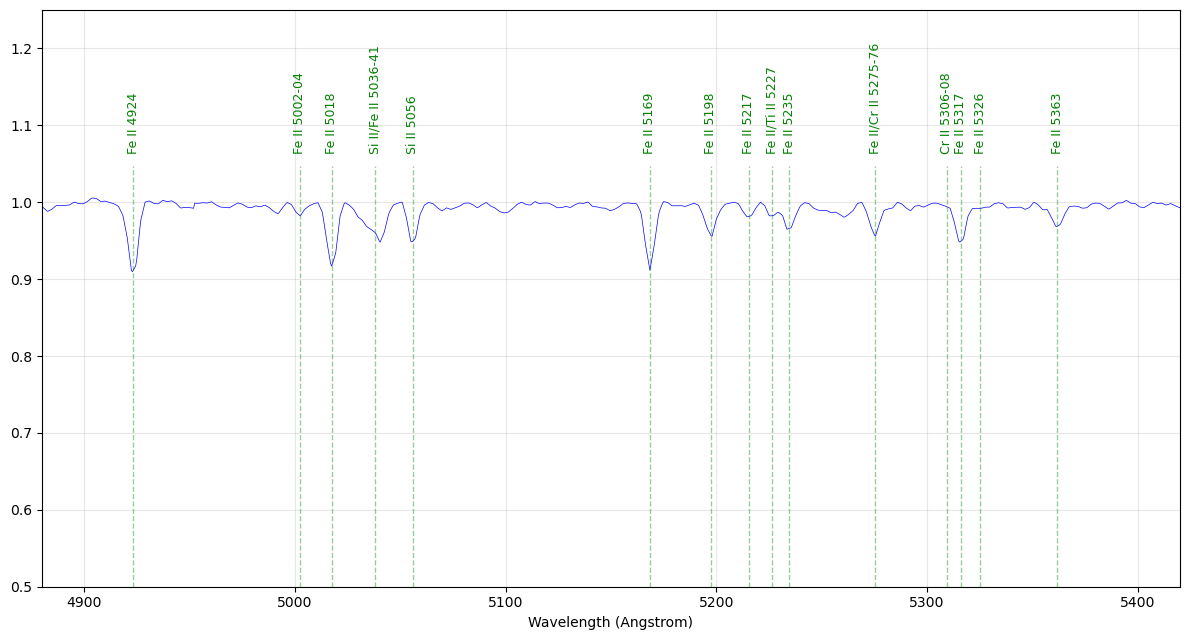

In [10]:
spec.plot_with_lines(wavelength, flux, spectral_lines_all, (4880,5420), (0.50,1.25))

### Zoom  540 - 600 nm

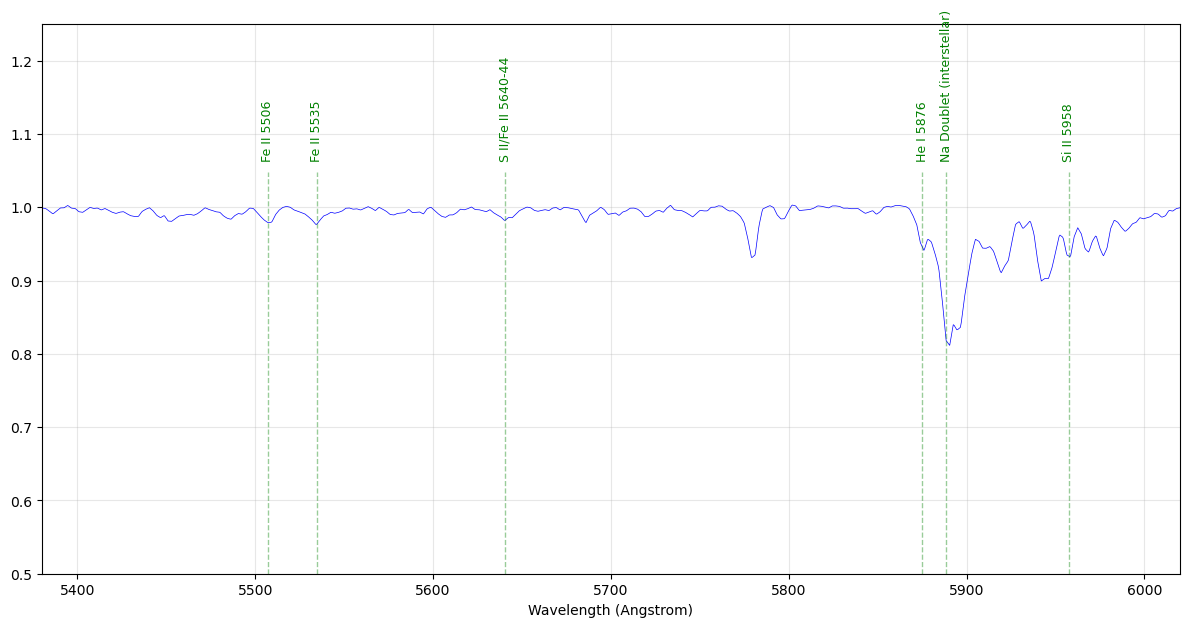

In [11]:
spec.plot_with_lines(wavelength, flux, spectral_lines_all, (5380,6020), (0.50,1.25))

### Zoom  600 - 670 nm

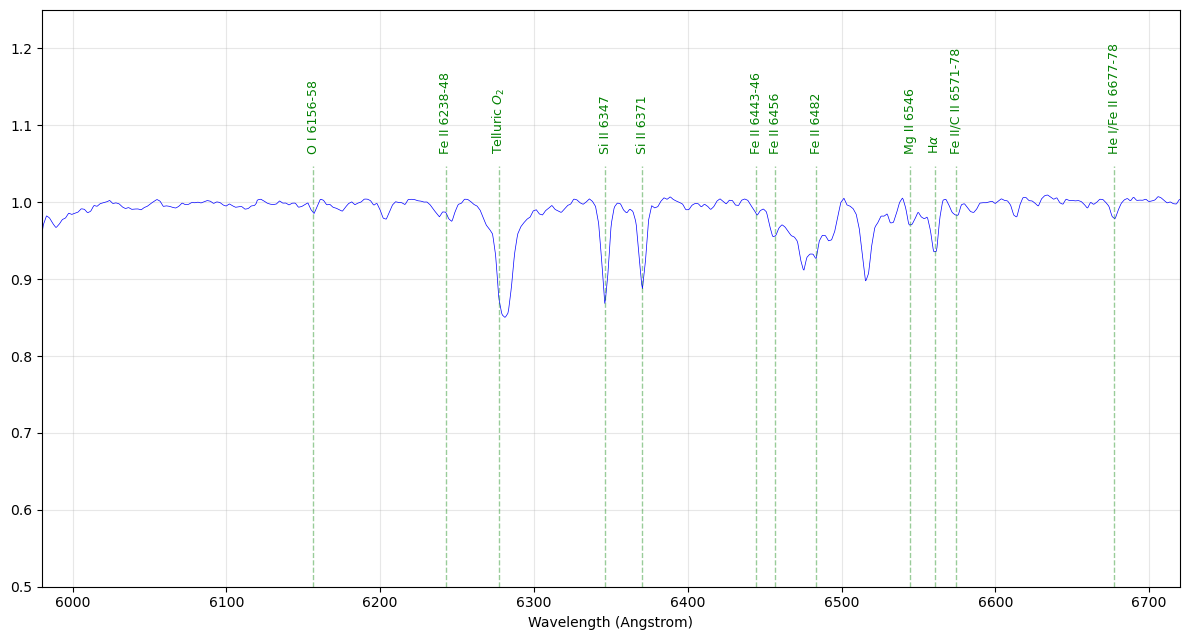

In [12]:
spec.plot_with_lines(wavelength, flux, spectral_lines_all, (5980,6720), (0.50,1.25))

## Line Measures

In [13]:
from spectral_lines import estimate_continuum
from spectral_lines import fit_all_identified_lines

fwhm_use =  7.0
amp = -2.3634950310353373 
mu = 4101.117998627466 
sigma = 2.147560082486172 
gamma = 1.1863450331435172 
offset = 1.00707418711286


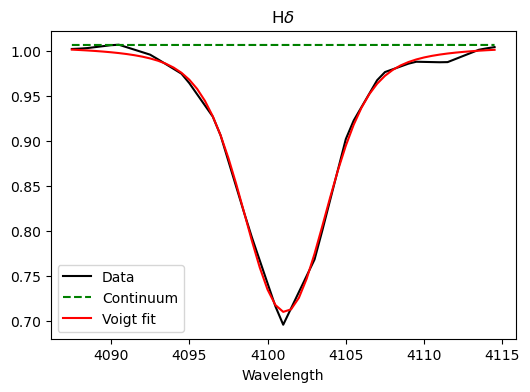

fwhm_use =  7.0
amp = -2.4503326433572186 
mu = 4340.17107007338 
sigma = 1.5414664932403879 
gamma = 1.9628785121072818 
offset = 1.0043577035021025


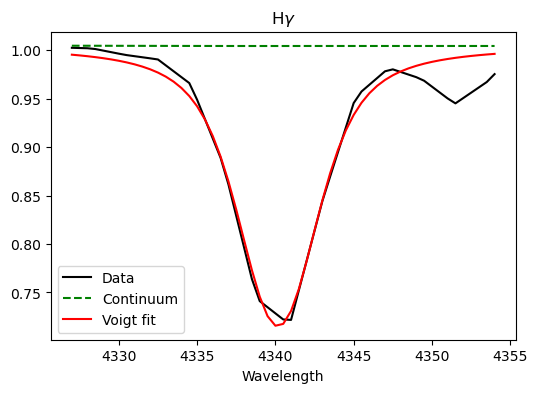

fwhm_use =  7.0
amp = -1.8357719733720526 
mu = 4860.806220438262 
sigma = 2.279743260564231 
gamma = 1.0476147449742221 
offset = 1.0020654906744517


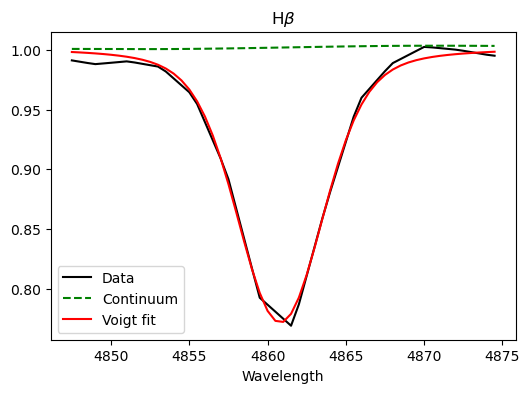

fwhm_use =  6.0
amp = -0.05224044395267184 
mu = 5056.04373290788 
sigma = 2.2291583674093696 
offset = 0.9995153155591211


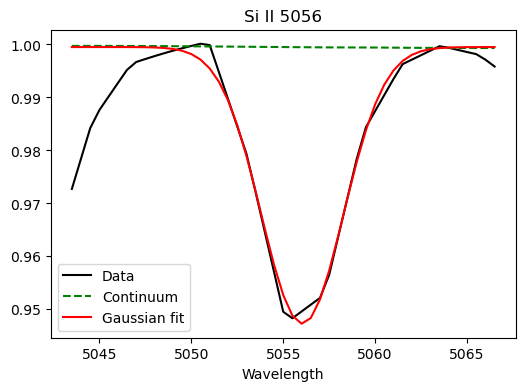

fwhm_use =  7.465882352941176
amp = -0.12507725443813494 
mu = 6346.236756041899 
sigma = 2.554988309198437 
offset = 1.003923793900202


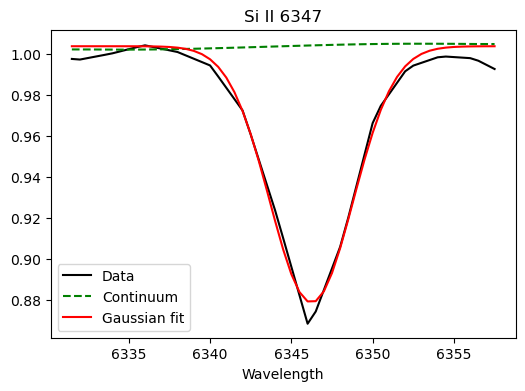

fwhm_use =  7.4941176470588236
amp = -0.10684920725266966 
mu = 6370.380876799594 
sigma = 2.7726500102521685 
offset = 1.005000939428405


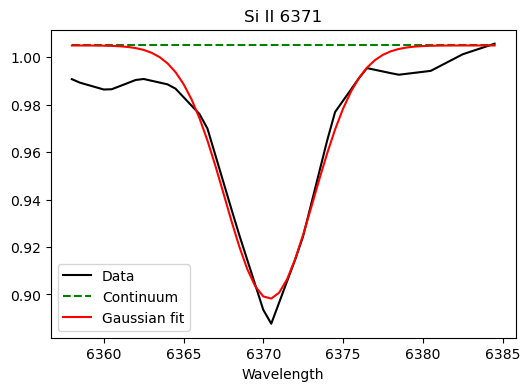

amp = -0.04461967413110753 
mu = 4471.550187937138 
sigma = 2.839190880426665 
offset = 1.0062483103457094


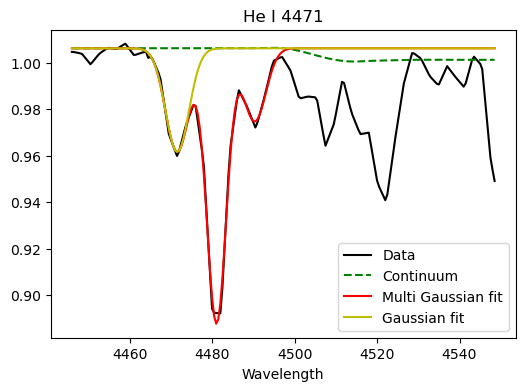

amp = -0.1183724317655757 
mu = 4481.070075768863 
sigma = 2.364154851723107 
offset = 1.0062483103457094


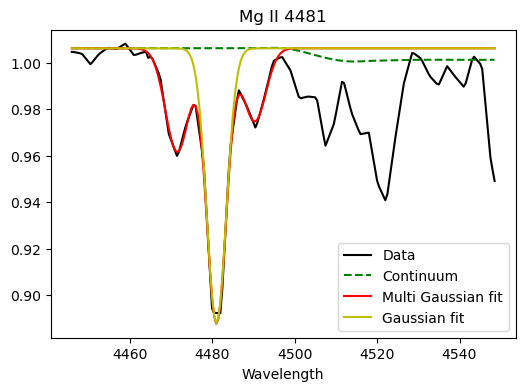

amp = -0.03150538245174909 
mu = 4490.33481576013 
sigma = 2.7136284202871064 
offset = 1.0062483103457094


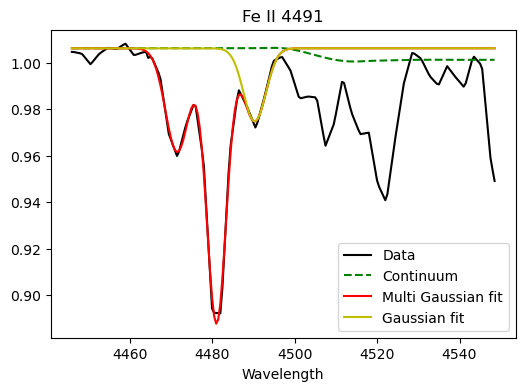

,Line,Lambda min,Lambda fit,EW,EW_Err,FWHM,FWHM_Err
0,H$\delta$,4101.00,4101.117999,2.346893,0.033623,6.444715,0.083105
1,H$\gamma$,4340.50,4340.171070,2.439701,0.042644,6.162470,0.079474
6,He I 4471,4471.00,4471.550188,0.315577,0.023029,6.686295,0.467410
7,Mg II 4481,4481.26,4481.070076,0.697126,0.022454,5.567585,0.187120
8,Fe II 4491,4491.40,4490.334816,0.212971,0.060236,6.390595,2.524800
2,H$\beta$,4861.00,4860.806220,1.831988,0.031462,6.576338,0.090079
3,Si II 5056,5055.00,5056.043733,0.292044,0.014786,5.249668,0.269507
4,Si II 6347,6346.00,6346.236756,0.797915,0.019824,6.016997,0.175104
5,Si II 6371,6370.00,6370.380877,0.738907,0.022004,6.529591,0.246182


In [14]:
spectral_lines_df = pd.read_csv('CE Cam spec - Measured.csv', names=["name","model","wavelength","group"])

spectral_lines = list(spectral_lines_df.itertuples(index=False, name=None))

line_window = 2.0          # angstroem tolerance for matching (+/- window)
smoothing_width = 3        # pixels for noise suppression
min_prominence = 0.01      # fraction of max flux

peak_wavelengths, peak_fluxes = spec.find_absorption_lines(
    wavelength, 
    flux, 
    smoothing_width = smoothing_width, 
    min_prominence = min_prominence )

identified_lines = spec.identify_absorption_lines(
    peak_wavelengths, 
    peak_fluxes, 
    spectral_lines, 
    z = 0.0, 
    line_window = line_window)

continuum_env = estimate_continuum(wavelength, flux, smooth_win_size=2, env_win_size = 15)

measures = fit_all_identified_lines(wavelength, flux, continuum_env, identified_lines)

df = pd.DataFrame(measures)
df = df.sort_values('Lambda fit')
df